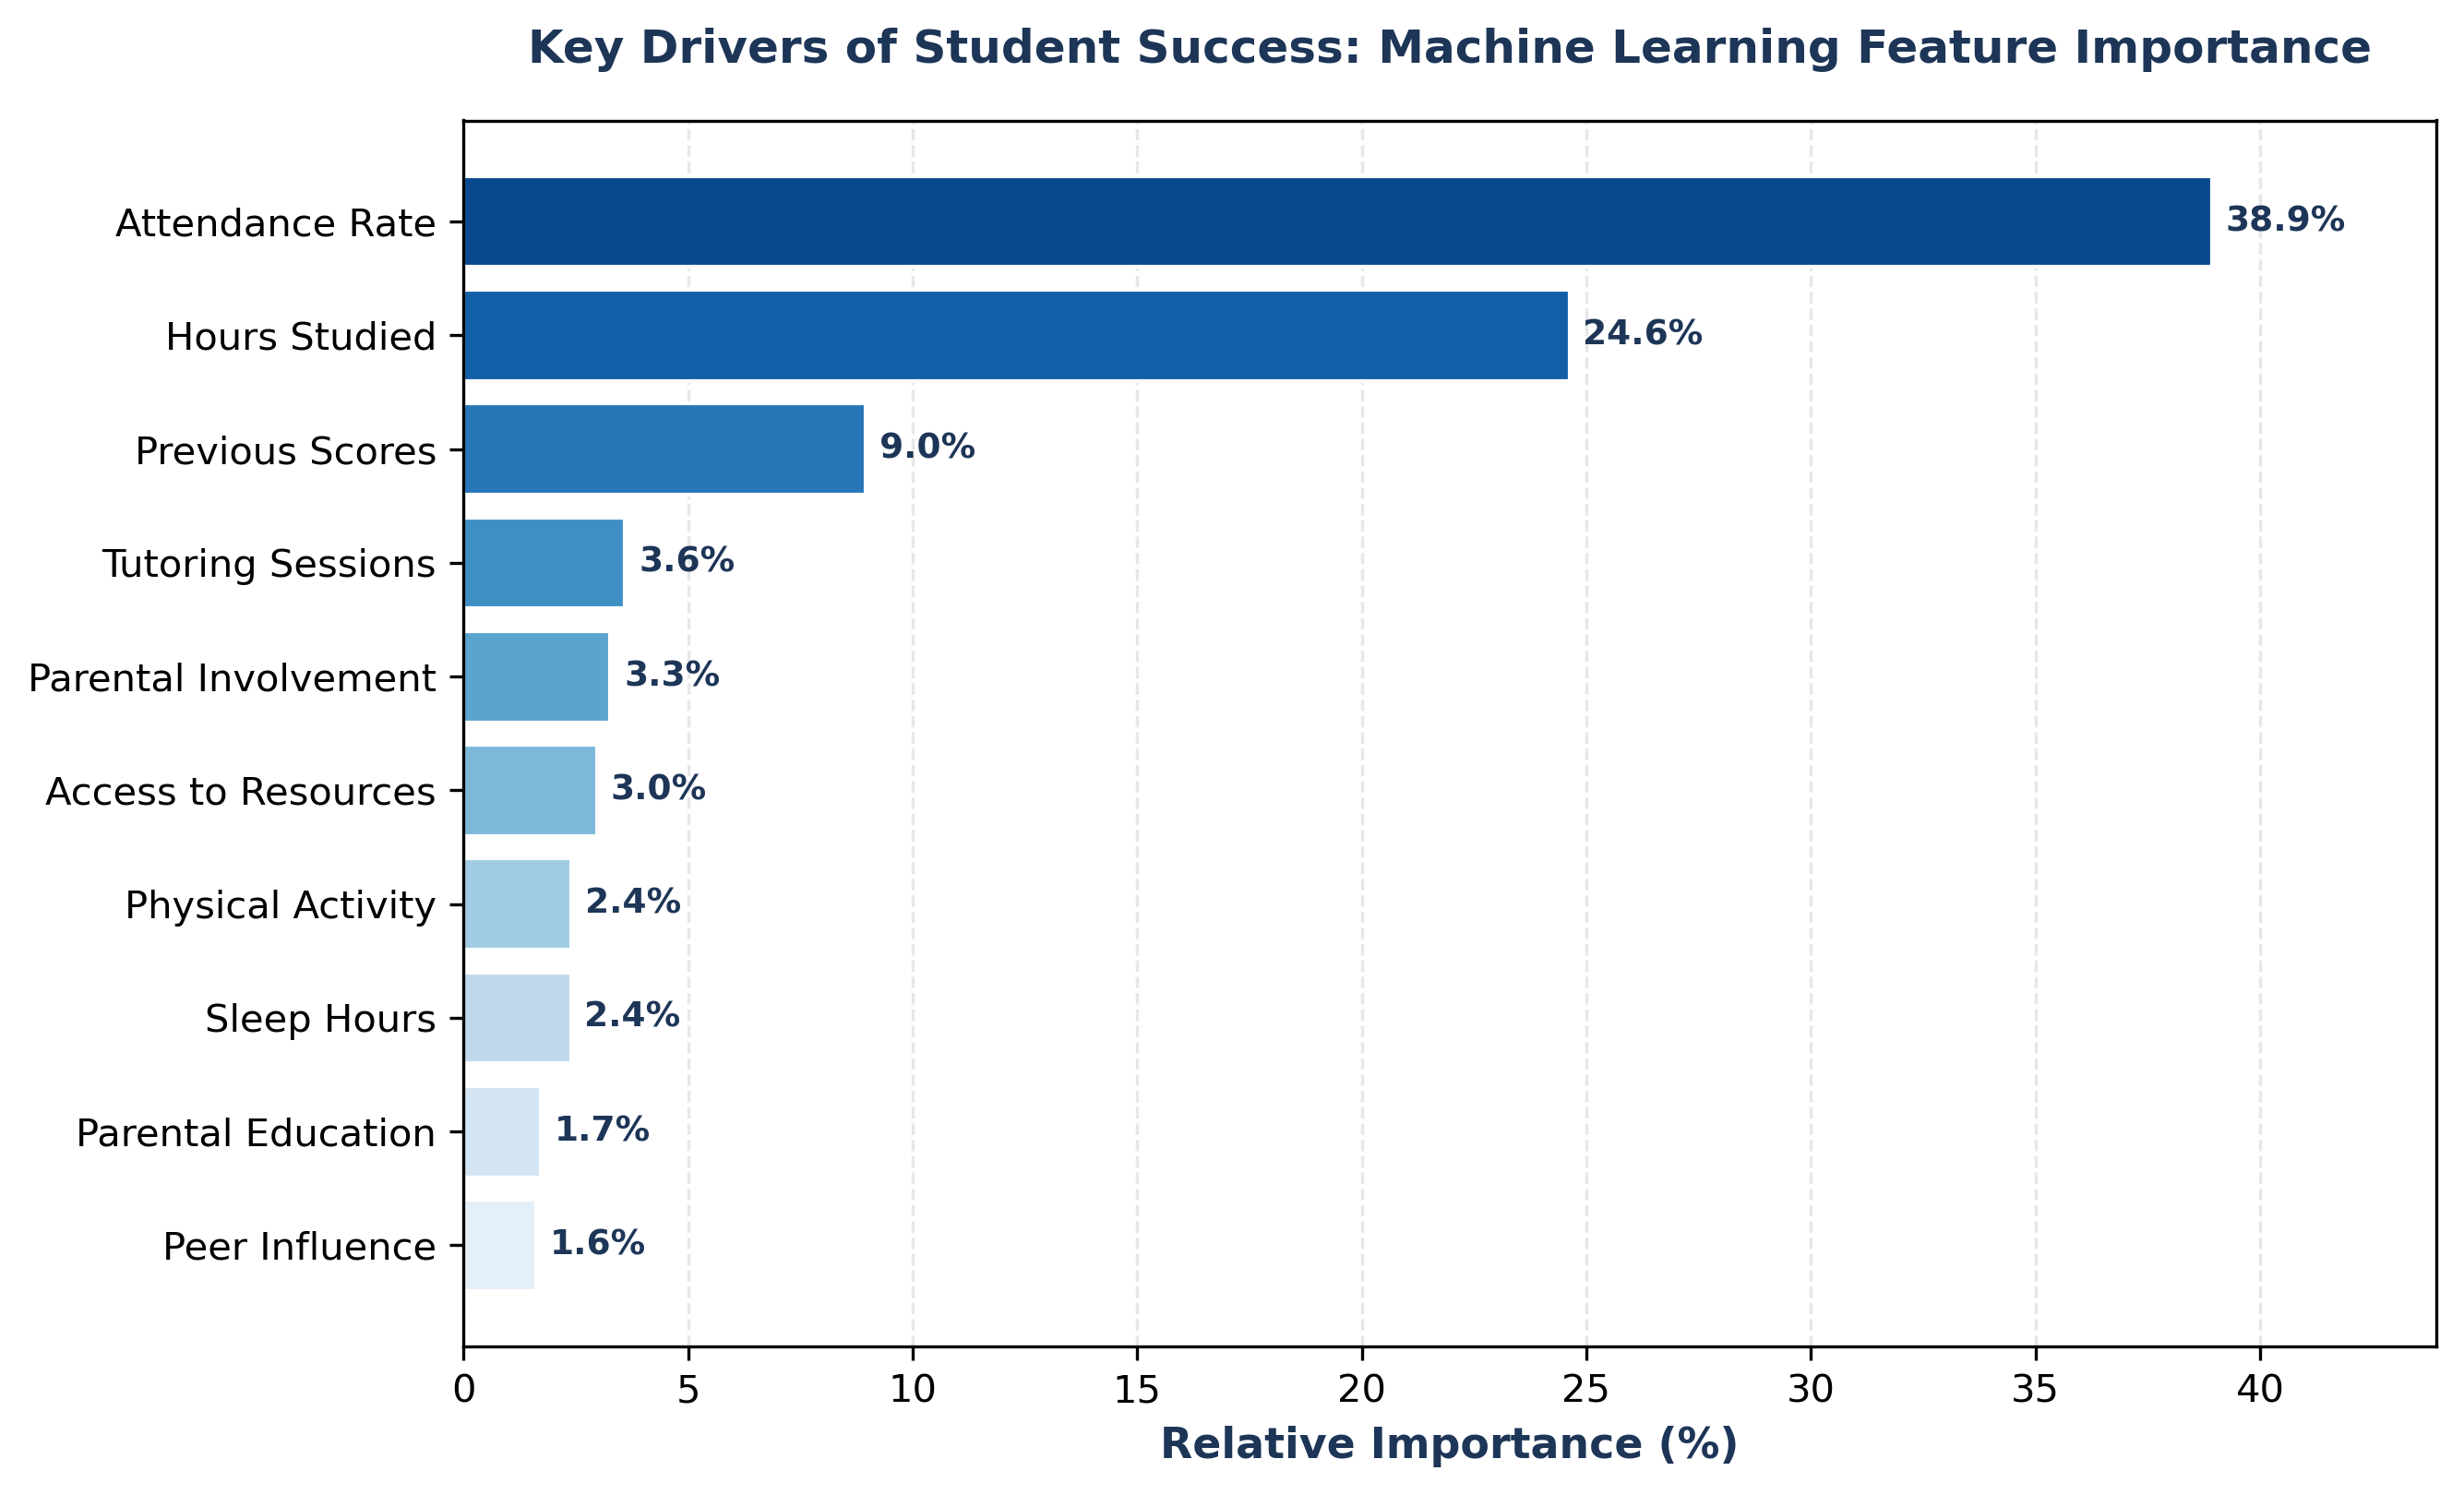

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('StudentPerformanceFactors.csv')

df_model = df.dropna(subset=['Exam_Score']).copy()

X = df_model.drop(columns=['Exam_Score'])
y = df_model['Exam_Score']

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].fillna(X[col].mode()[0])
    else:
        X[col] = X[col].fillna(X[col].median())

X_encoded = pd.get_dummies(X, drop_first=True)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_encoded, y)

feature_importances = pd.Series(rf.feature_importances_, index=X_encoded.columns)

orig_importances = {}
for col in X.columns:
    matching_cols = [c for c in X_encoded.columns if c == col or c.startswith(col + '_')]
    orig_importances[col] = feature_importances[matching_cols].sum()

importance_df = pd.DataFrame(list(orig_importances.items()), columns=['Feature', 'Importance']).sort_values('Importance', ascending=False)

name_map = {
    'Hours_Studied': 'Hours Studied',
    'Attendance': 'Attendance Rate',
    'Sleep_Hours': 'Sleep Hours',
    'Previous_Scores': 'Previous Scores',
    'Tutoring_Sessions': 'Tutoring Sessions',
    'Physical_Activity': 'Physical Activity',
    'Parental_Involvement': 'Parental Involvement',
    'Access_to_Resources': 'Access to Resources',
    'Motivation_Level': 'Motivation Level',
    'Family_Income': 'Family Income',
    'Teacher_Quality': 'Teacher Quality',
    'Peer_Influence': 'Peer Influence',
    'Distance_from_Home': 'Distance from Home',
    'School_Type': 'School Type',
    'Parental_Education_Level': 'Parental Education',
    'Internet_Access': 'Internet Access',
    'Learning_Disabilities': 'Learning Disabilities',
    'Gender': 'Gender',
    'Extracurricular_Activities': 'Extracurricular Activities'
}

importance_df['Feature_Label'] = importance_df['Feature'].map(lambda x: name_map.get(x, x))
top_features = importance_df.head(10).sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 5.5), dpi=300)

palette = sns.color_palette("Blues", len(top_features))

bars = plt.barh(top_features['Feature_Label'], top_features['Importance'] * 100, color=palette, edgecolor='white')

plt.title("Key Drivers of Student Success: Machine Learning Feature Importance", fontsize=12, fontweight='bold', pad=15, color='#1D3557')
plt.xlabel("Relative Importance (%)", fontsize=11, fontweight='bold', color='#1D3557')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', 
             va='center', ha='left', fontsize=9, fontweight='bold', color='#1D3557')

plt.xlim(0, max(top_features['Importance'] * 100) + 5)
plt.gca().set_axisbelow(True)
plt.grid(True, linestyle='--', alpha=0.3, axis='x')

plt.tight_layout()
plt.show()